### Unsupervised Learning 
#### Date: 2026-01-26

**Topics**:
> 1. Unsupervised Learning
> 2. Clustering
> 3. Anomaly Detection 

**Materials**:
> 1. [Unsupervised Learning](https://www.geeksforgeeks.org/machine-learning/unsupervised-learning/)
> 3. [Anomaly Detection](https://www.ibm.com/think/topics/anomaly-detection)

##### Кластеризація 
Кластеризація — це задача, у якій:
> немає правильних відповідей \
> ми хочемо розбити обʼєкти на групи схожих \
> алгоритм сам шукає схожість


| Клієнт | К-сть сесій | Час перегляду (хв) | Днів з останньої |
| ------ | ----------- | ------------------ | ---------------- |
| A      | 20          | 3000               | 1                |
| B      | 2           | 150                | 40               |
| C      | 8           | 900                | 7                |


Коли кластеризація має сенс
> сегментація користувачів \
> сегментація товарів \
> пошук патернів поведінки \
> попередній аналіз перед ML-моделями

Якщо ви не можете пояснити кластер словами — він вам не потрібен

Основне це використання ознак
> sessions_per_week \
> watch_time_minutes \
> days_since_last_activity \
> avg_session_duration

**Погані ознаки:**
> user_id \
> email_length \
> випадкові числа

##### K-means
K-Means намагається розбити обʼєкти на k груп так, щоб усередині груп обʼєкти були максимально схожі між собою

> у вас є користувачі \
> кожен користувач — це точка \
> координати точки — це ознаки (активність, гроші, час)

K-Means:
> ставить k центрів \
> притягує кожну точку до найближчого центру \
> пересуває центри в середину груп \
> повторює, поки нічого не змінюється

In [9]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [10]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [11]:
features = ["total_bill", "tip", "size"]
X = df[features]
X.head()

,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Inertia:**
Наскільки далеко точки від своїх центрів
> менше -> краще \
> але завжди зменшується, якщо збільшувати k

In [15]:
from sklearn.cluster import KMeans

inertias = []

K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    
print(inertias)

[372.8670448878256, 280.451049796167, 232.53441144774214, 196.6759269451793, 175.52040271650804, 152.74605082787912, 138.3417613656692]


In [16]:
KMeans?

Init signature:
KMeans(
    n_clusters=8,
    *,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)
Docstring:     
K-Means clustering.

Read more in the :ref:`User Guide <k_means>`.

Parameters
----------

n_clusters : int, default=8
    The number of clusters to form as well as the number of
    centroids to generate.

    For an example of how to choose an optimal value for `n_clusters` refer to
    :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.

init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
    Method for initialization:

    * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to the overall inertia. This technique speeds up             convergence. The algorithm imple

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

df[["total_bill", "tip", "size", "cluster"]].head()

,total_bill,tip,size,cluster
0,16.99,1.01,2,2
1,10.34,1.66,3,2
2,21.01,3.50,3,0
3,23.68,3.31,2,0
4,24.59,3.61,4,1


In [23]:
from sklearn.metrics import silhouette_score

silhouette_score(X_scaled, df["cluster"])

# 1 - good
# 0 - cluster with problem
# <0 - bad

# 3 clusters: 0.35; 4 clusters: 0.36

0.3549055441253416

In [29]:
cluster_summary = (
    df
    .groupby("cluster")[features]
    .mean()
)

cluster_summary


,total_bill,tip,size
cluster,,,
0,21.026304,3.337826,2.260870
1,28.115333,3.891778,4.022222
2,12.675102,1.922041,2.020408
3,42.888889,6.778889,4.444444


##### DBSCAN

**K-Means:**
> змушує кожну точку належати до кластера 

**DBSCAN:**
>  сам знаходить кількість кластерів


**DBSCAN варто використати:**
> є викиди (дуже великі / дивні значення) \
> кластери не круглі \
> важливо знайти аномальні обʼєкти


| Параметр      |  Пояснення                                      |
| ------------- | ----------------------------------------------- |
| `eps`         | радіус “сусідства”                              |
| `min_samples` | скільки точок має бути поруч, щоб це була група |


In [30]:
features = ["total_bill", "tip", "size"]
X = df[features]

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
DBSCAN?

Init signature:
DBSCAN(
    eps=0.5,
    *,
    min_samples=5,
    metric='euclidean',
    metric_params=None,
    algorithm='auto',
    leaf_size=30,
    p=None,
    n_jobs=None,
)
Docstring:     
Perform DBSCAN clustering from vector array or distance matrix.

DBSCAN - Density-Based Spatial Clustering of Applications with Noise.
Finds core samples of high density and expands clusters from them.
Good for data which contains clusters of similar density.

This implementation has a worst case memory complexity of :math:`O({n}^2)`,
which can occur when the `eps` param is large and `min_samples` is low,
while the original DBSCAN only uses linear memory.
For further details, see the Notes below.

Read more in the :ref:`User Guide <dbscan>`.

Parameters
----------
eps : float, default=0.5
    The maximum distance between two samples for one to be considered
    as in the neighborhood of the other. This is not a maximum bound
    on the distances of points within a cluster. This is the most
 

In [32]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.7, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = labels

In [36]:
df["dbscan_cluster"].value_counts()

dbscan_cluster
 0    152
-1     33
 2     33
 1     26
Name: count, dtype: int64

In [43]:
df['total_bill'].mean()

np.float64(19.78594262295082)

In [44]:
df.groupby('dbscan_cluster')['total_bill'].mean()

dbscan_cluster
-1    29.492121
 0    16.135395
 1    19.324615
 2    27.257879
Name: total_bill, dtype: float64

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

In [53]:
kmeans = KMeans(n_clusters = 3, random_state = 42)
clusters = kmeans.fit_predict(X_scaled)

In [55]:
from matplotlib import pyplot as plt

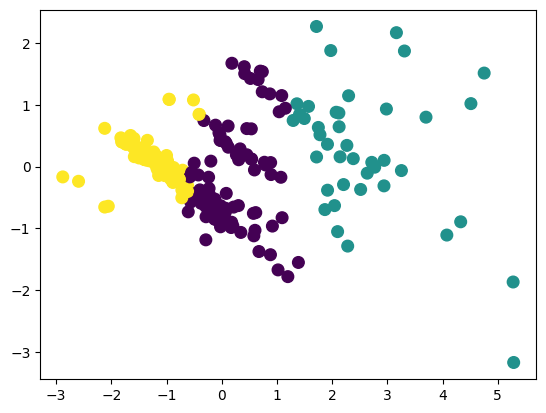

In [59]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c = clusters,
    s = 70
);

<Axes: xlabel='total_bill', ylabel='tip'>

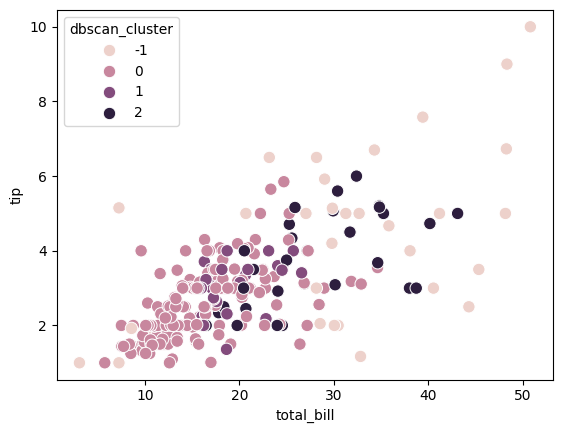

In [49]:
sns.scatterplot(
    data = df,
    x = 'total_bill',
    y = 'tip',
    hue = 'dbscan_cluster',
    s = 80
)

In [45]:
df.groupby('dbscan_cluster')['size'].mean()

dbscan_cluster
-1    3.424242
 0    2.000000
 1    3.000000
 2    4.000000
Name: size, dtype: float64

In [42]:
df[df['dbscan_cluster'] == -1]

,total_bill,tip,sex,smoker,day,time,size,cluster,dbscan_cluster
1,10.34,1.66,Male,No,Sun,Dinner,3,2,-1
16,10.33,1.67,Female,No,Sun,Dinner,3,2,-1
23,39.42,7.58,Male,No,Sat,Dinner,4,3,-1
39,31.27,5.00,Male,No,Sat,Dinner,3,1,-1
48,28.55,2.05,Male,No,Sun,Dinner,3,0,-1
59,48.27,6.73,Male,No,Sat,Dinner,4,3,-1
67,3.07,1.00,Female,Yes,Sat,Dinner,1,2,-1
82,10.07,1.83,Female,No,Thur,Lunch,1,2,-1
83,32.68,5.00,Male,Yes,Thur,Lunch,2,0,-1
102,44.30,2.50,Female,Yes,Sat,Dinner,3,1,-1


In [34]:
(df["dbscan_cluster"] == -1).mean()

np.float64(0.13524590163934427)

In [37]:
df.groupby("dbscan_cluster")[features].mean()

,total_bill,tip,size
dbscan_cluster,,,
-1,29.492121,4.254242,3.424242
0,16.135395,2.556053,2.000000
1,19.324615,3.056538,3.000000
2,27.257879,3.733333,4.000000


In [38]:
anomalies = df[df["dbscan_cluster"] == -1]
anomalies.head()

,total_bill,tip,sex,smoker,day,time,size,cluster,dbscan_cluster
1,10.34,1.66,Male,No,Sun,Dinner,3,2,-1
16,10.33,1.67,Female,No,Sun,Dinner,3,2,-1
23,39.42,7.58,Male,No,Sat,Dinner,4,3,-1
39,31.27,5.00,Male,No,Sat,Dinner,3,1,-1
48,28.55,2.05,Male,No,Sun,Dinner,3,0,-1


##### Anomaly detection 

---
**Точкові аномалії (Point anomalies)**
Окремий обʼєкт, який різко відрізняється від інших

---
**Контекстні аномалії (Contextual anomalies)**
Аномалія залежить від контексту:
> часу \
> категорії \
> локації

**Приклад:**
> 10 покупок о 3 ночі — нормально для Black Friday \
> 10 покупок о 3 ночі в звичайний день — аномалія

---
**Колективні аномалії (Collective anomalies)**
Група обʼєктів, яка разом виглядає дивно.

**Приклад:**
> серія дивних транзакцій \
> послідовність логін -> покупка -> повернення 100 разів


**Головні проблеми**
> Немає правильних відповідей (labels) \
> Невідомо, скільки аномалій \
> Аномалії змінюються з часом \
> Аномалія для одного бізнесу — норма для іншого

##### Статистичний підхід
Більшість значень лежить у нормальному діапазоні.
Все, що далеко — підозріле.

**Типові методи**
> Z-score \
> IQR (квартильний розмах) \
> Percentile rules

##### Distance-based
Аномалії — це точки, які далеко від інших

**Алгоритми**
> KNN-based \
> LOF (Local Outlier Factor) \
> DBSCAN (через шум)


##### Tree-based
Аномальні обʼєкти легше ізолювати, ніж нормальні

> будуємо багато випадкових дерев \
> нормальна точка, багато розділень \
> аномалія, ізолюється швидко

In [60]:
import pandas as pd

In [ ]:
def load_from_file(path: str  = "creditcard.csv") -> pd.DataFrame:
    df = pd.read_csv(path)
    return df

In [69]:
def quick_eda(df: pd.DataFrame):
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\nClass distribution:")
    print(df["Class"].value_counts())
    # print("\nFraud rate:", (df["Class"].mean() * 100).round(4), "%")
    print("\nAmount summary:")
    print(df["Amount"].describe())

In [67]:
df = load_from_file()

In [71]:
df['Class'] = df['Class'].str.replace("'", "")

In [70]:
quick_eda(df)

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class distribution:
Class
'0'    284315
'1'       492
Name: count, dtype: int64

Amount summary:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,'0'
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,'0'
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,'0'
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,'0'
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,'0'


In [72]:
def time_split(df: pd.DataFrame, test_size=0.2):
    df_sorted = df.sort_values("Time").reset_index(drop=True)
    cut = int(len(df_sorted) * (1 - test_size))
    train = df_sorted.iloc[:cut].copy()
    test  = df_sorted.iloc[cut:].copy()
    return train, test

train_df, test_df = time_split(df, test_size=0.2)

In [73]:
feature_cols = [c for c in df.columns if c.startswith("V")] + ["Amount", "Time"]

In [74]:
feature_cols

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Time']

In [75]:
X_train = train_df[feature_cols]
y_train = train_df["Class"].astype(int)

X_test  = test_df[feature_cols]
y_test  = test_df["Class"].astype(int)

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [77]:
def report_binary(y_true, y_pred, y_score=None, title=""):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print("\n" + "="*60)
    if title:
        print(title)
    print("Confusion matrix [ [TN FP]\n[FN TP] ]")
    print(cm)
    print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
    print(f"Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")

    if y_score is not None:
        try:
            roc = roc_auc_score(y_true, y_score)
        except Exception:
            roc = None
        ap  = average_precision_score(y_true, y_score)
        if roc is not None:
            print(f"ROC-AUC={roc:.4f}")
        print(f"PR-AUC (Average Precision)={ap:.4f}")
        

In [83]:
import numpy as np
import pandas as pd

In [88]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score 

In [ ]:
def iqr_amount_detector(train_amount: pd.Series, test_amount: pd.Series, k=1.5):
    q1 = train_amount.quantile(0.25)
    q3 = train_amount.quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
   
    score = np.abs(test_amount - test_amount.median())  
    pred = ((test_amount < low) | (test_amount > high)).astype(int).values
    return pred, score, (low, high)


# q1 +/- 1.5 * IQR
iqr_pred, iqr_score, (low, high) = iqr_amount_detector(train_df["Amount"], test_df["Amount"], k=3.0)
report_binary(y_test.values, iqr_pred, y_score=iqr_score, title="IQR on Amount (k=3.0)")


IQR on Amount (k=3.0)
Confusion matrix [ [TN FP]
[FN TP] ]
[[53769  3118]
 [   68     7]]
TN=53769 FP=3118 FN=68 TP=7
Precision=0.0022  Recall=0.0933  F1=0.0044
ROC-AUC=0.6025
PR-AUC (Average Precision)=0.0019


In [90]:
from sklearn.neighbors import NearestNeighbors

In [91]:
def knn_distance_detector(X_train_s, X_test_s, contamination=0.001, n_neighbors=10):
    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(X_train_s)
    dists, _ = nn.kneighbors(X_test_s)
    score = dists[:, -1] 
    thr = np.quantile(score, 1 - contamination)
    pred = (score >= thr).astype(int)
    return pred, score, thr

knn_pred, knn_score, knn_thr = knn_distance_detector(X_train_scaled, X_test_scaled, contamination=0.001, n_neighbors=10)
report_binary(y_test.values, knn_pred, y_score=knn_score, title=f"KNN distance (thr={knn_thr:.4f})")



KNN distance (thr=13.5955)
Confusion matrix [ [TN FP]
[FN TP] ]
[[56830    57]
 [   75     0]]
TN=56830 FP=57 FN=75 TP=0
Precision=0.0000  Recall=0.0000  F1=0.0000
ROC-AUC=0.9390
PR-AUC (Average Precision)=0.0617


In [92]:
from sklearn.neighbors import LocalOutlierFactor

def lof_detector(X_train_s, X_test_s, contamination=0.001, n_neighbors=20):
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination, novelty=True)
    lof.fit(X_train_s)
    normality = lof.decision_function(X_test_s)
    score = -normality
    pred = (lof.predict(X_test_s) == -1).astype(int)
    return pred, score

lof_pred, lof_score = lof_detector(X_train_scaled, X_test_scaled, contamination=0.001, n_neighbors=20)
report_binary(y_test.values, lof_pred, y_score=lof_score, title="LOF (novelty=True)")



LOF (novelty=True)
Confusion matrix [ [TN FP]
[FN TP] ]
[[56800    87]
 [   75     0]]
TN=56800 FP=87 FN=75 TP=0
Precision=0.0000  Recall=0.0000  F1=0.0000
ROC-AUC=0.4963
PR-AUC (Average Precision)=0.0013


In [97]:
from sklearn.cluster import DBSCAN

def dbscan_detector(X_test_s, eps=2.5, min_samples=10):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_test_s)
    
    pred = (labels == -1).astype(int)
    score = pred.astype(float)
    return pred, score, labels

db_pred, db_score, db_labels = dbscan_detector(X_test_scaled, eps=4.5, min_samples=10)
report_binary(y_test.values, db_pred, y_score=db_score, title="DBSCAN: noise as anomalies (eps=2.5, min_samples=10)")
print("DBSCAN clusters (including noise=-1):", pd.Series(db_labels).value_counts().head())



DBSCAN: noise as anomalies (eps=2.5, min_samples=10)
Confusion matrix [ [TN FP]
[FN TP] ]
[[55595  1292]
 [   14    61]]
TN=55595 FP=1292 FN=14 TP=61
Precision=0.0451  Recall=0.8133  F1=0.0854
ROC-AUC=0.8953
PR-AUC (Average Precision)=0.0369
DBSCAN clusters (including noise=-1):  0    55537
-1     1353
 3       36
 2       26
 1       10
Name: count, dtype: int64


In [104]:
IsolationForest?

Init signature:
IsolationForest(
    *,
    n_estimators=100,
    max_samples='auto',
    contamination='auto',
    max_features=1.0,
    bootstrap=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
)
Docstring:     
Isolation Forest Algorithm.

Return the anomaly score of each sample using the IsolationForest algorithm

The IsolationForest 'isolates' observations by randomly selecting a feature
and then randomly selecting a split value between the maximum and minimum
values of the selected feature.

Since recursive partitioning can be represented by a tree structure, the
number of splittings required to isolate a sample is equivalent to the path
length from the root node to the terminating node.

This path length, averaged over a forest of such random trees, is a
measure of normality and our decision function.

Random partitioning produces noticeably shorter paths for anomalies.
Hence, when a forest of random trees collectively produce shorter path
len

In [106]:
from sklearn.ensemble import IsolationForest

def isolation_forest_detector(X_train_s, X_test_s, contamination=0.001, n_estimators=500, random_state=42):
    iso = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )
    iso.fit(X_train_s)
    normality = iso.score_samples(X_test_s)
    score = -normality
    pred = (iso.predict(X_test_s) == -1).astype(int)
    return pred, score

iso_pred, iso_score = isolation_forest_detector(X_train_scaled, X_test_scaled, contamination=0.1)
report_binary(y_test.values, iso_pred, y_score=iso_score, title="Tree-based: Isolation Forest")



Tree-based: Isolation Forest
Confusion matrix [ [TN FP]
[FN TP] ]
[[50503  6384]
 [    9    66]]
TN=50503 FP=6384 FN=9 TP=66
Precision=0.0102  Recall=0.8800  F1=0.0202
ROC-AUC=0.9495
PR-AUC (Average Precision)=0.0449


In [112]:
def show_top_anomalies(test_df: pd.DataFrame, score: np.ndarray, top_n=10, title=""):
    tmp = test_df.copy()
    tmp["score"] = score
    tmp = tmp.sort_values("score", ascending=False).head(top_n)
    cols = ["Time", "Amount", "Class", "score"] + [c for c in tmp.columns if c.startswith("V")][:5]
    print("\n" + "-"*60)
    print(title)
    print(tmp[cols])

show_top_anomalies(test_df, iso_score, top_n=10, title="Top anomalies by Isolation Forest (highest score = most suspicious)")


------------------------------------------------------------
Top anomalies by Isolation Forest (highest score = most suspicious)
            Time    Amount Class     score         V1         V2         V3  \
274771  166198.0  25691.16     0  0.770718 -35.548539 -31.850484 -48.325589   
231455  146772.0   3552.96     0  0.744586 -35.905105 -31.041362 -19.472908   
228723  145630.0   7367.00     0  0.721198 -32.543140 -50.383269 -10.733302   
232014  147012.0   1201.93     0  0.720319 -21.066749 -17.193065  -9.769594   
262378  160444.0   2074.69     0  0.719929 -28.623353 -19.262983 -13.042666   
227921  145283.0  10000.00     0  0.719829 -21.532478 -34.704768  -8.303035   
262838  160669.0   1441.06     0  0.719403 -31.972536 -22.709113 -13.942635   
229859  146082.0   2687.48     0  0.719280 -18.065915 -20.943103  -4.581048   
262843  160672.0   1441.06     0  0.719106 -34.092032 -24.237418 -15.758012   
228158  145381.0   8182.70     0  0.718996 -13.710746 -21.177912  -9.340628   



In [102]:
show_top_anomalies(test_df, lof_score, top_n=10, title="Top anomalies by LOF")


------------------------------------------------------------
Top anomalies by LOF
            Time  Amount Class      score        V1        V2        V3  \
237187  149132.0   21.00     0  19.874969  2.105179 -0.179539 -2.534754   
246284  153113.0    1.99     0  19.341553  2.155109 -0.001860 -2.545855   
271080  164401.0   17.90     0  11.950669  1.976000  0.023367 -1.335581   
284292  172308.0    0.99     0   9.957431  2.118376 -0.092093 -1.904607   
274856  166244.0   31.01     0   9.852143  2.069159 -0.141300 -2.460895   
281528  170241.0    1.00     0   9.819884  2.068937 -0.137922 -1.460791   
282321  170815.0   44.99     0   9.776089  1.979871 -0.286580 -1.561556   
284110  172160.0    7.99     0   9.772389  2.045388 -0.156988 -1.481416   
277665  167785.0    1.00     0   9.478669  2.016454 -0.146430 -1.280967   
274100  165853.0  135.00     0   9.040173  1.836216 -0.527030 -1.777940   

              V4        V5  
237187 -0.247827  1.001453  
246284 -0.116684  1.122787  
2710

In [110]:
df.iloc[[274771, 227921], :]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
274771,166198.0,-35.548539,-31.850484,-48.325589,15.304184,-113.743307,73.301626,120.589494,-27.347360,-3.872425,...,-21.620120,5.712303,-1.581098,4.584549,4.554683,3.415636,31.612198,-15.430084,25691.16,0
227921,145283.0,-21.532478,-34.704768,-8.303035,10.264175,3.957175,-3.229695,-4.066768,-4.083971,0.554072,...,5.198718,-7.331078,-32.828995,0.118986,-8.696627,-1.778061,-0.519786,2.716716,10000.00,0


In [103]:
show_top_anomalies(test_df, knn_score, top_n=10, title="Top anomalies by KNN distance")


------------------------------------------------------------
Top anomalies by KNN distance
            Time    Amount Class       score         V1         V2         V3  \
274771  166198.0  25691.16     0  176.837157 -35.548539 -31.850484 -48.325589   
227921  145283.0  10000.00     0   51.054121 -21.532478 -34.704768  -8.303035   
284250  172273.0  10199.44     0   40.788621  -9.030538 -11.112584 -16.233798   
233904  147747.0     12.31     0   40.727710  -3.226248  -4.185371   2.846206   
228723  145630.0   7367.00     0   39.777163 -32.543140 -50.383269 -10.733302   
231455  146772.0   3552.96     0   33.105645 -35.905105 -31.041362 -19.472908   
262843  160672.0   1441.06     0   30.322501 -34.092032 -24.237418 -15.758012   
234519  148008.0    157.43     0   30.217704 -40.470142 -37.520432 -17.474421   
262838  160669.0   1441.06     0   29.440407 -31.972536 -22.709113 -13.942635   
229034  145773.0   1210.00     0   29.397934 -32.058119 -48.060856  -6.939376   

               V